# DCGAN para CelebA (PyTorch) – Kaggle
- Dataset: `jessicali9530/celeba-dataset` (20k imagens, 64×64)
- Arquitetura DCGAN original
- FID nativo para monitoramento
- Treinamento otimizado para GPU T4

In [1]:
import os

# Listar todos os arquivos no /kaggle/input
print("📂 Estrutura completa do /kaggle/input:")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for file in files:
        if file.endswith(".csv"):
            print(f"{subindent}{file}")
            print(f"      → Caminho completo: {os.path.join(root, file)}")

📂 Estrutura completa do /kaggle/input:
input/
  datasets/
    pedrohgms/
      currated-files/
        curated_files.csv
      → Caminho completo: /kaggle/input/datasets/pedrohgms/currated-files/curated_files.csv
    jessicali9530/
      celeba-dataset/
        list_landmarks_align_celeba.csv
      → Caminho completo: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_landmarks_align_celeba.csv
        list_eval_partition.csv
      → Caminho completo: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_eval_partition.csv
        list_attr_celeba.csv
      → Caminho completo: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv
        list_bbox_celeba.csv
      → Caminho completo: /kaggle/input/datasets/jessicali9530/celeba-dataset/list_bbox_celeba.csv
        img_align_celeba/
          img_align_celeba/


In [2]:
import os

# 1. Aponte diretamente para a pasta que contém as imagens .jpg
BASE_DIR = "/kaggle/input/datasets/jessicali9530/celeba-dataset"
DATA_DIR = os.path.join(BASE_DIR, "img_align_celeba", "img_align_celeba")

# 2. Verificação de segurança (opcional, mas recomendada)
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Caminho não encontrado: {DATA_DIR}. Verifique o caminho no Kaggle.")

# 3. Listar arquivos .jpg
all_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith('.jpg')])

print(f"Diretório encontrado: {DATA_DIR}")
print(f"Número de imagens JPG: {len(all_files)}")
print(f"Primeiras imagens: {all_files[:5]}")

Diretório encontrado: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
Número de imagens JPG: 202599
Primeiras imagens: ['000001.jpg', '000002.jpg', '000003.jpg', '000004.jpg', '000005.jpg']


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import os
import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# Configurações e hiperparâmetros (seguindo artigo original)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

# Caminho base do dataset
BASE_DIR = "/kaggle/input/datasets/jessicali9530/celeba-dataset"
SUBSET_SIZE = 20000        # usar 20k imagens para treino rápido
IMAGE_SIZE = 64
BATCH_SIZE = 128
NUM_WORKERS = 4

# Modelo
LATENT_DIM = 100
LR = 0.0002
BETA1 = 0.5
EPOCHS = 100

# FID
FID_SAMPLES = 5000         # imagens usadas no cálculo
FID_BATCH = 64

# Diretório de saída
OUT_DIR = "./output_dcgan"
os.makedirs(OUT_DIR, exist_ok=True)

Usando: cuda


In [5]:
# Encontrar automaticamente a pasta que contém os .jpg
def find_jpg_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.lower().endswith('.jpg') for f in filenames):
            return dirpath
    return None

DATA_DIR = find_jpg_dir(BASE_DIR)
if DATA_DIR is None:
    candidate = os.path.join(BASE_DIR, "img_align_celeba", "img_align_celeba")
    if os.path.isdir(candidate):
        DATA_DIR = candidate
    else:
        DATA_DIR = os.path.join(BASE_DIR, "img_align_celeba")

print(f"DATA_DIR: {DATA_DIR}")

# ==============================================
# Leitura do CSV com coluna 'file name'
# ==============================================
csv_path = "/kaggle/input/datasets/pedrohgms/currated-files/curated_files.csv"

# Lê o CSV e extrai a coluna 'file name'
df = pd.read_csv(csv_path)
selected_files = df["filename"].tolist()   # <- nome exato da coluna

print(f"📄 Lidas {len(selected_files)} entradas do CSV.")

# Limitar para SUBSET_SIZE (20k)
if len(selected_files) > SUBSET_SIZE:
    selected_files = selected_files[:SUBSET_SIZE]

# Verificar se os arquivos realmente existem (proteção contra nomes inconsistentes)
existing_files = []
missing = 0
for f in selected_files:
    if os.path.exists(os.path.join(DATA_DIR, f)):
        existing_files.append(f)
    else:
        missing += 1

if missing > 0:
    print(f"⚠️ Aviso: {missing} arquivos listados no CSV não foram encontrados. Usando os {len(existing_files)} existentes.")
    selected_files = existing_files

print(f"🚀 Carregando {len(selected_files)} imagens da lista curada.")

# Atribui para a variável que será usada no dataset
all_files = selected_files

DATA_DIR: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
📄 Lidas 15336 entradas do CSV.
🚀 Carregando 15336 imagens da lista curada.


In [6]:
# Transformações: CenterCrop(140), Resize(64), ToTensor, Normalize [-1,1]
transform = transforms.Compose([
    transforms.CenterCrop(140),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Dataset customizado (evita ImageFolder, que exige subpastas)
class CelebADataset(torch.utils.data.Dataset):
    def __init__(self, root, file_list, transform=None):
        self.root = root
        self.file_list = file_list
        self.transform = transform
    def __len__(self):
        return len(self.file_list)
    def __getitem__(self, idx):
        img_path = os.path.join(self.root, self.file_list[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0  # label dummy

dataset = CelebADataset(DATA_DIR, all_files, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

# Dataloader fixo para FID (sem shuffle)
fid_real_dataset = CelebADataset(DATA_DIR, all_files[:FID_SAMPLES], transform=transform)
fid_real_loader = DataLoader(fid_real_dataset, batch_size=FID_BATCH, shuffle=False, num_workers=2)

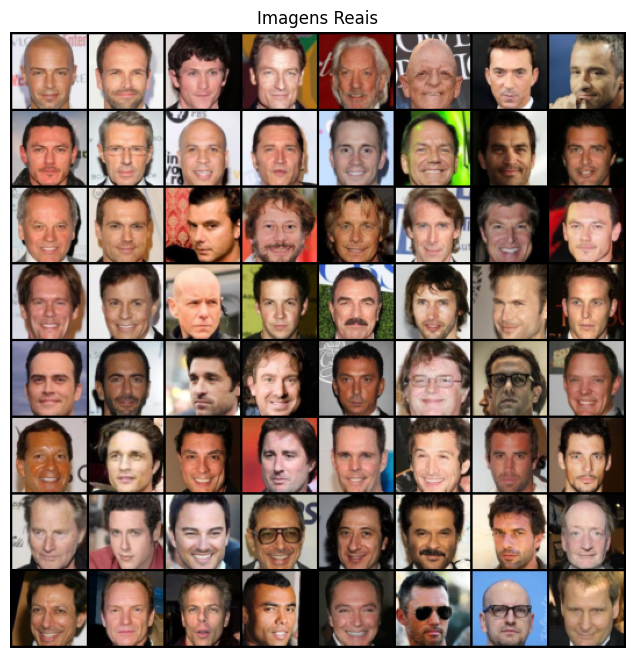

In [7]:
# Visualizar um batch de imagens reais
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Imagens Reais")
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.imshow(np.transpose(grid, (1,2,0)))
plt.savefig(os.path.join(OUT_DIR, "real_samples.png"))
plt.show()

## 2. Modelos (Gerador e Discriminador)

In [8]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # z (100,1,1) -> (1024,4,4)
            nn.ConvTranspose2d(LATENT_DIM, 1024, 4, 1, 0, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(True),
            # (1024,4,4) -> (512,8,8)
            nn.ConvTranspose2d(1024, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # (512,8,8) -> (256,16,16)
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # (256,16,16) -> (128,32,32)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # (128,32,32) -> (3,64,64)
            nn.ConvTranspose2d(128, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # 3x64x64 -> (64,32,32)
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (64,32,32) -> (128,16,16)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # (128,16,16) -> (256,8,8)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # (256,8,8) -> (512,4,4)
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # (512,4,4) -> 1x1x1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


# Inicialização de pesos (N(0,0.02))
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Instanciar e aplicar inicialização
netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 1024, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()


## 3. Função de perda e otimizadores

In [9]:
criterion = nn.BCELoss()
optD = optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optG = optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

# Label smoothing unilateral: reais = 0.9, falsos = 0.0
real_label = 0.9
fake_label = 0.0

## 4. Cálculo do FID (implementação nativa)

In [10]:
import torchvision.models as models
from torchvision.models import Inception_V3_Weights
from scipy import linalg

# Inception V3 pré-treinado (features 2048-dim)
inception = models.inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, transform_input=False)
inception.fc = nn.Identity()
inception.eval()
inception.to(device)

def get_features(loader, model, num_samples):
    features = []
    count = 0
    with torch.no_grad():
        for images, _ in loader:
            if count >= num_samples:
                break
            images = images.to(device)
            up = nn.functional.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
            pred = model(up)
            features.append(pred.cpu().numpy())
            count += images.size(0)
    features = np.concatenate(features, axis=0)[:num_samples]
    return features

def calculate_fid(real_features, fake_features):
    mu1, sigma1 = np.mean(real_features, axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = np.mean(fake_features, axis=0), np.cov(fake_features, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = np.real(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2*covmean))
    return fid

# Extrair features reais uma vez (fixas durante treino)
print("Extraindo features reais para FID...")
real_features_fid = get_features(fid_real_loader, inception, FID_SAMPLES)
print("Features reais extraídas.")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 180MB/s]


Extraindo features reais para FID...
Features reais extraídas.


## 5. Funções auxiliares (visualização e FID da época)

In [11]:
# Ruído fixo para acompanhar evolução
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

def save_generated_images(epoch, noise, path):
    with torch.no_grad():
        fake = netG(noise).detach().cpu()
    grid = vutils.make_grid(fake, padding=2, normalize=True)
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title(f"Época {epoch}")
    plt.imshow(np.transpose(grid, (1,2,0)))
    plt.savefig(path)
    plt.close()

def compute_fid_epoch(gen, num_samples=FID_SAMPLES):
    gen.eval()
    fake_features = []
    count = 0
    with torch.no_grad():
        while count < num_samples:
            z = torch.randn(FID_BATCH, LATENT_DIM, 1, 1, device=device)
            fake = gen(z)
            up = nn.functional.interpolate(fake, size=(299, 299), mode='bilinear', align_corners=False)
            pred = inception(up)
            fake_features.append(pred.cpu().numpy())
            count += fake.size(0)
    fake_features = np.concatenate(fake_features, axis=0)[:num_samples]
    gen.train()
    return calculate_fid(real_features_fid, fake_features)

# Histórico
g_losses = []
d_losses = []
fid_scores = []

## 6. Loop de Treinamento

In [12]:
print("Iniciando treinamento...")
for epoch in range(1, EPOCHS+1):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(dataloader, desc=f"Época {epoch}/{EPOCHS}")
    for real_images, _ in pbar:
        real_images = real_images.to(device)
        batch_size_curr = real_images.size(0)
        
        # ---------------------
        # Treino Discriminador
        # ---------------------
        netD.zero_grad()
        
        # Reais (label suavizado)
        label = torch.full((batch_size_curr,), real_label, device=device)
        output_real = netD(real_images).view(-1)
        d_loss_real = criterion(output_real, label)
        d_loss_real.backward()
        
        # Falsas
        z = torch.randn(batch_size_curr, LATENT_DIM, 1, 1, device=device)
        fake_images = netG(z)
        label.fill_(fake_label)
        output_fake = netD(fake_images.detach()).view(-1)
        d_loss_fake = criterion(output_fake, label)
        d_loss_fake.backward()
        
        d_loss = d_loss_real + d_loss_fake
        optD.step()
        
        # ---------------------
        # Treino Gerador
        # ---------------------
        netG.zero_grad()
        label.fill_(real_label)  # quer enganar como real
        z = torch.randn(batch_size_curr, LATENT_DIM, 1, 1, device=device)
        fake_images = netG(z)
        output = netD(fake_images).view(-1)
        g_loss = criterion(output, label)
        g_loss.backward()
        optG.step()
        
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        num_batches += 1
        pbar.set_postfix(D_loss=f"{d_loss.item():.3f}", G_loss=f"{g_loss.item():.3f}")
    
    # Médias da época
    avg_d_loss = epoch_d_loss / num_batches
    avg_g_loss = epoch_g_loss / num_batches
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)
    
    # FID da época
    fid = compute_fid_epoch(netG)
    fid_scores.append(fid)
    
    print(f"[Época {epoch}] D_loss: {avg_d_loss:.4f} | G_loss: {avg_g_loss:.4f} | FID: {fid:.2f}")
    
    # Salvar amostras
    if epoch % 5 == 0 or epoch == 1:
        save_generated_images(epoch, fixed_noise, os.path.join(OUT_DIR, f"fake_epoch_{epoch}.png"))
    
    # Checkpoint
    if epoch % 10 == 0:
        torch.save(netG.state_dict(), os.path.join(OUT_DIR, f"generator_epoch_{epoch}.pth"))
        torch.save(netD.state_dict(), os.path.join(OUT_DIR, f"discriminator_epoch_{epoch}.pth"))

print("Treinamento concluído!")

Iniciando treinamento...


Época 1/100: 100%|██████████| 120/120 [00:44<00:00,  2.71it/s, D_loss=0.906, G_loss=6.373]
/tmp/ipykernel_23/2095081008.py:30: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


[Época 1] D_loss: 1.3439 | G_loss: 11.9385 | FID: 320.70


Época 2/100: 100%|██████████| 120/120 [00:54<00:00,  2.19it/s, D_loss=1.650, G_loss=4.142]


[Época 2] D_loss: 1.1498 | G_loss: 3.5020 | FID: 260.74


...

[Época 98] D_loss: 0.6369 | G_loss: 2.6147 | FID: 13.10


Época 99/100: 100%|██████████| 120/120 [00:54<00:00,  2.18it/s, D_loss=0.910, G_loss=3.431]


[Época 99] D_loss: 0.7046 | G_loss: 2.5794 | FID: 14.03


Época 100/100: 100%|██████████| 120/120 [00:55<00:00,  2.18it/s, D_loss=0.573, G_loss=2.144]


[Época 100] D_loss: 0.6446 | G_loss: 2.5796 | FID: 13.72
Treinamento concluído!


## 7. Gráficos de perda e FID

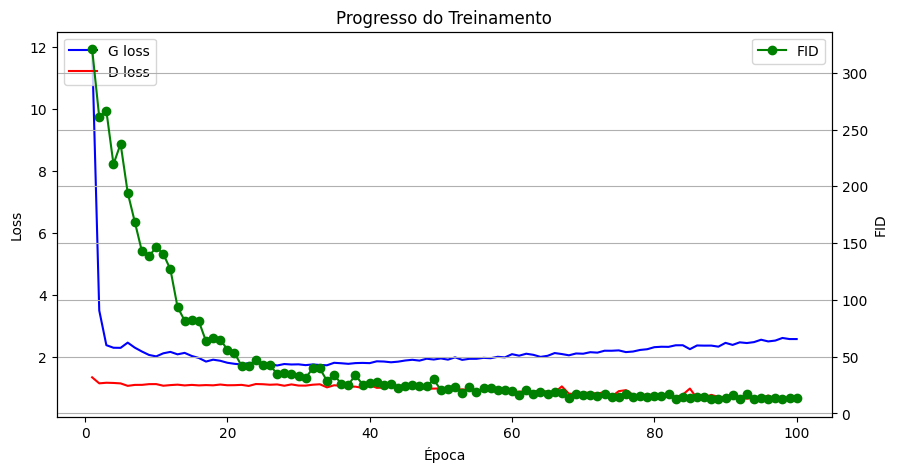

In [13]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(range(1, EPOCHS+1), g_losses, label='G loss', color='blue')
ax1.plot(range(1, EPOCHS+1), d_losses, label='D loss', color='red')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(range(1, EPOCHS+1), fid_scores, label='FID', color='green', marker='o')
ax2.set_ylabel('FID')
ax2.legend(loc='upper right')
plt.title('Progresso do Treinamento')
plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "training_plot.png"))
plt.show()

## 8. Geração final de amostras

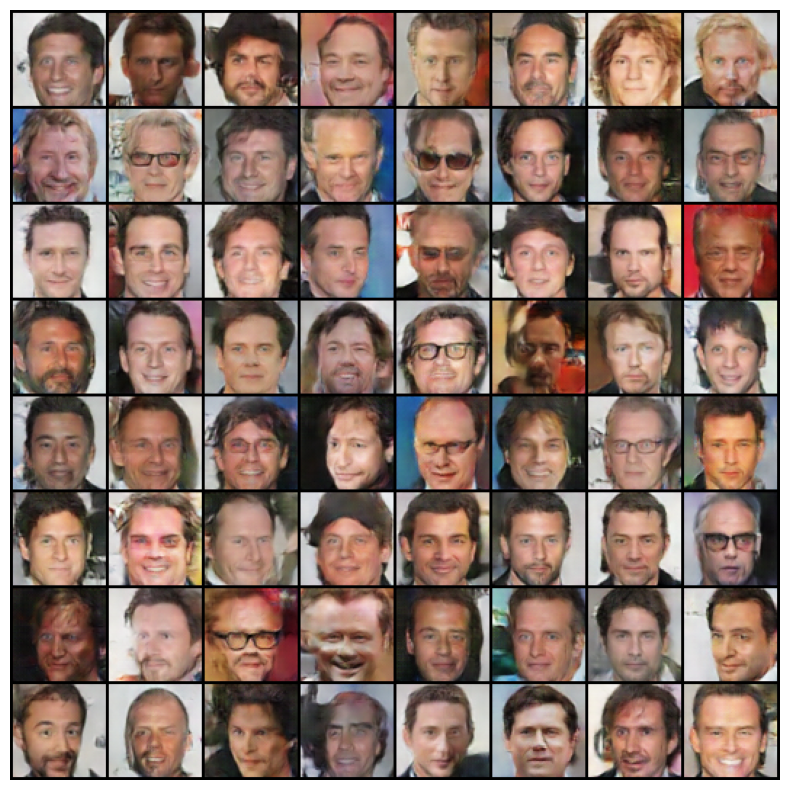

In [14]:
netG.eval()
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    samples = netG(z).cpu()
grid = vutils.make_grid(samples, padding=2, normalize=True)
plt.figure(figsize=(10,10))
plt.axis('off')
plt.imshow(np.transpose(grid, (1,2,0)))
plt.savefig(os.path.join(OUT_DIR, "final_generated.png"))
plt.show()